In [15]:
# Cell 1: Import all necessary libraries
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle
import os  # ← Added this
from pathlib import Path
import matplotlib.pyplot as plt

print("="*70)
print(" " * 10 + "SHOT PUT VIDEO ANALYSIS - INFERENCE PIPELINE")
print("="*70)

print("\n📦 Importing libraries...")
print(f"✓ OpenCV version: {cv2.__version__}")
print(f"✓ MediaPipe version: {mp.__version__}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ OS module imported")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

print("\n✅ All libraries imported!")
print("="*70)

          SHOT PUT VIDEO ANALYSIS - INFERENCE PIPELINE

📦 Importing libraries...
✓ OpenCV version: 4.11.0
✓ MediaPipe version: 0.10.21
✓ PyTorch version: 2.6.0+cpu
✓ NumPy version: 1.26.4
✓ Pandas version: 2.2.3
✓ OS module imported
✓ Device: cpu

✅ All libraries imported!


In [16]:
# Cell 2: Initialize MediaPipe Pose for keypoint extraction
print("="*70)
print("🔧 STEP 1: INITIALIZING MEDIAPIPE POSE")
print("="*70)

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

# Create pose detector
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("\n✓ MediaPipe Pose initialized")

# Define the keypoint mapping
KEYPOINT_MAPPING = {
    'left_shoulder': mp_pose.PoseLandmark.LEFT_SHOULDER,
    'right_shoulder': mp_pose.PoseLandmark.RIGHT_SHOULDER,
    'left_elbow': mp_pose.PoseLandmark.LEFT_ELBOW,
    'right_elbow': mp_pose.PoseLandmark.RIGHT_ELBOW,
    'left_wrist': mp_pose.PoseLandmark.LEFT_WRIST,
    'right_wrist': mp_pose.PoseLandmark.RIGHT_WRIST,
    'left_hip': mp_pose.PoseLandmark.LEFT_HIP,
    'right_hip': mp_pose.PoseLandmark.RIGHT_HIP,
    'left_knee': mp_pose.PoseLandmark.LEFT_KNEE,
    'right_knee': mp_pose.PoseLandmark.RIGHT_KNEE,
    'left_ankle': mp_pose.PoseLandmark.LEFT_ANKLE,
    'right_ankle': mp_pose.PoseLandmark.RIGHT_ANKLE,
    'left_heel': mp_pose.PoseLandmark.LEFT_HEEL,
    'right_heel': mp_pose.PoseLandmark.RIGHT_HEEL,
    'left_foot_index': mp_pose.PoseLandmark.LEFT_FOOT_INDEX,
    'right_foot_index': mp_pose.PoseLandmark.RIGHT_FOOT_INDEX,
    'nose': mp_pose.PoseLandmark.NOSE,
}

print(f"✓ Keypoint mapping defined")
print("\n✅ MediaPipe ready!")
print("="*70)

🔧 STEP 1: INITIALIZING MEDIAPIPE POSE

✓ MediaPipe Pose initialized
✓ Keypoint mapping defined

✅ MediaPipe ready!


In [17]:
# Cell 3 (Fixed): Function to extract keypoints with CORRECT FPS calculation
print("="*70)
print("📹 STEP 2: VIDEO PROCESSING FUNCTION (CORRECTED FPS)")
print("="*70)

def extract_keypoints_from_video(video_path, target_fps=30, save_excel=True, excel_path='extracted_keypoints.xlsx'):
    """
    Extract 20 keypoints from video at specified FPS (matching training data)
    FIXED: Correct frame interval calculation
    """
    
    print(f"\n🎬 Processing video: {video_path}")
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("❌ Error: Could not open video file!")
        return None, 0
    
    # Get video properties
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / video_fps if video_fps > 0 else 0
    
    print(f"✓ Video opened successfully")
    print(f"  • Original FPS: {video_fps:.2f}")
    print(f"  • Total frames: {total_frames}")
    print(f"  • Duration: {duration:.2f} seconds")
    print(f"  • Target FPS: {target_fps}")
    
    # FIXED: Correct frame interval calculation
    frame_interval = max(1, round(video_fps / target_fps))  # Changed from int() to round()
    expected_frames = int(duration * target_fps)
    
    print(f"  • Frame interval: {frame_interval} (extracting every {frame_interval} frame)")
    print(f"  • Expected frames: ~{expected_frames}")
    
    # Storage for keypoints
    all_keypoints = []
    frame_count = 0
    extracted_count = 0
    
    print(f"\n🔄 Extracting keypoints...")
    
    while cap.isOpened():
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Extract every Nth frame based on interval
        if frame_count % frame_interval == 0:
            # Convert BGR to RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Process with MediaPipe
            results = pose.process(rgb_frame)
            
            if results.pose_landmarks:
                landmarks = results.pose_landmarks.landmark
                
                # Build keypoint row with ALL 20 keypoints (40 features)
                keypoint_row = {'frame_name': f'f{extracted_count+1}.jpg'}
                
                # 1-2: Shoulders
                keypoint_row['left_shoulder_x'] = landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER].x
                keypoint_row['left_shoulder_y'] = landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER].y
                keypoint_row['right_shoulder_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x
                keypoint_row['right_shoulder_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y
                
                # 3-4: Elbows
                keypoint_row['left_elbow_x'] = landmarks[mp_pose.PoseLandmark.LEFT_ELBOW].x
                keypoint_row['left_elbow_y'] = landmarks[mp_pose.PoseLandmark.LEFT_ELBOW].y
                keypoint_row['right_elbow_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
                keypoint_row['right_elbow_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y
                
                # 5-6: Wrists
                keypoint_row['left_wrist_x'] = landmarks[mp_pose.PoseLandmark.LEFT_WRIST].x
                keypoint_row['left_wrist_y'] = landmarks[mp_pose.PoseLandmark.LEFT_WRIST].y
                keypoint_row['right_wrist_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
                keypoint_row['right_wrist_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y
                
                # 7-8: Hips
                keypoint_row['left_hip_x'] = landmarks[mp_pose.PoseLandmark.LEFT_HIP].x
                keypoint_row['left_hip_y'] = landmarks[mp_pose.PoseLandmark.LEFT_HIP].y
                keypoint_row['right_hip_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_HIP].x
                keypoint_row['right_hip_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_HIP].y
                
                # 9-10: Knees
                keypoint_row['left_knee_x'] = landmarks[mp_pose.PoseLandmark.LEFT_KNEE].x
                keypoint_row['left_knee_y'] = landmarks[mp_pose.PoseLandmark.LEFT_KNEE].y
                keypoint_row['right_knee_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_KNEE].x
                keypoint_row['right_knee_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_KNEE].y
                
                # 11-12: Ankles
                keypoint_row['left_ankle_x'] = landmarks[mp_pose.PoseLandmark.LEFT_ANKLE].x
                keypoint_row['left_ankle_y'] = landmarks[mp_pose.PoseLandmark.LEFT_ANKLE].y
                keypoint_row['right_ankle_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE].x
                keypoint_row['right_ankle_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE].y
                
                # 13: Top of head
                keypoint_row['top_of_head_x'] = landmarks[mp_pose.PoseLandmark.NOSE].x
                keypoint_row['top_of_head_y'] = landmarks[mp_pose.PoseLandmark.NOSE].y
                
                # 14: Center of hips
                left_hip = landmarks[mp_pose.PoseLandmark.LEFT_HIP]
                right_hip = landmarks[mp_pose.PoseLandmark.RIGHT_HIP]
                keypoint_row['center_of_hips_x'] = (left_hip.x + right_hip.x) / 2
                keypoint_row['center_of_hips_y'] = (left_hip.y + right_hip.y) / 2
                
                # 15-16: Big toes
                keypoint_row['left_big_toe_x'] = landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX].x
                keypoint_row['left_big_toe_y'] = landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX].y
                keypoint_row['right_big_toe_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX].x
                keypoint_row['right_big_toe_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX].y
                
                # 17-18: Small toes
                keypoint_row['left_small_toe_x'] = landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX].x
                keypoint_row['left_small_toe_y'] = landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX].y
                keypoint_row['right_small_toe_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX].x
                keypoint_row['right_small_toe_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX].y
                
                # 19-20: Heels
                keypoint_row['left_heel_x'] = landmarks[mp_pose.PoseLandmark.LEFT_HEEL].x
                keypoint_row['left_heel_y'] = landmarks[mp_pose.PoseLandmark.LEFT_HEEL].y
                keypoint_row['right_heel_x'] = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL].x
                keypoint_row['right_heel_y'] = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL].y
                
                all_keypoints.append(keypoint_row)
                extracted_count += 1
                
                if extracted_count % 10 == 0:
                    print(f"  Processed {extracted_count} frames...", end='\r')
        
        frame_count += 1
    
    cap.release()
    
    print(f"\n✓ Video processing complete!")
    print(f"  • Total video frames: {frame_count}")
    print(f"  • Keypoints extracted: {extracted_count} frames")
    print(f"  • Match expected: {abs(extracted_count - expected_frames) <= 2} (±2 frames tolerance)")
    
    if len(all_keypoints) == 0:
        print("❌ No keypoints extracted!")
        return None, 0
    
    # Create DataFrame
    keypoints_df = pd.DataFrame(all_keypoints)
    
    print(f"\n✓ DataFrame created: {keypoints_df.shape}")
    print(f"  • Columns: {len(keypoints_df.columns)} (1 frame_name + 40 features)")
    
    # Save to Excel
    if save_excel:
        keypoints_df.to_excel(excel_path, index=False)
        print(f"✓ Keypoints saved to: {excel_path}")
    
    return keypoints_df, extracted_count

print("\n✅ Video processing function ready (CORRECTED FPS calculation)!")
print("="*70)

📹 STEP 2: VIDEO PROCESSING FUNCTION (CORRECTED FPS)

✅ Video processing function ready (CORRECTED FPS calculation)!


In [18]:
# Cell 4: Process a new athlete's video
print("="*70)
print("🎥 STEP 3: PROCESS NEW ATHLETE VIDEO")
print("="*70)

# ========================================
# INPUT YOUR VIDEO PATH HERE
# ========================================
VIDEO_PATH = r"F:\Deepak_Pendrive\video\v56.MOV"
EXCEL_OUTPUT = 'athlete_keypoints.xlsx'
TARGET_FPS = 30
# ========================================

print(f"\n📂 Video settings:")
print(f"  • Input video: {VIDEO_PATH}")
print(f"  • Output Excel: {EXCEL_OUTPUT}")
print(f"  • Target FPS: {TARGET_FPS}")

# Check if video file exists
if not os.path.exists(VIDEO_PATH):
    print(f"\n❌ ERROR: Video file not found at '{VIDEO_PATH}'")
else:
    print(f"\n✓ Video file found!")
    
    # Extract keypoints from video
    print("\n" + "="*70)
    keypoints_df, frame_count = extract_keypoints_from_video(
        video_path=VIDEO_PATH,
        target_fps=TARGET_FPS,
        save_excel=True,
        excel_path=EXCEL_OUTPUT
    )
    
    if keypoints_df is not None:
        print("\n" + "="*70)
        print("📊 KEYPOINTS EXTRACTION SUMMARY")
        print("="*70)
        print(f"\n✓ Successfully extracted keypoints from {frame_count} frames")
        print(f"✓ DataFrame shape: {keypoints_df.shape}")
        print(f"✓ Excel file saved: {EXCEL_OUTPUT}")
        
        print(f"\n📋 Preview of extracted data (first 3 rows):")
        print(keypoints_df.head(3))
        
        print(f"\n✅ Keypoints ready for model prediction!")
    else:
        print("\n❌ Failed to extract keypoints from video")

print("\n" + "="*70)

🎥 STEP 3: PROCESS NEW ATHLETE VIDEO

📂 Video settings:
  • Input video: F:\Deepak_Pendrive\video\v56.MOV
  • Output Excel: athlete_keypoints.xlsx
  • Target FPS: 30

✓ Video file found!


🎬 Processing video: F:\Deepak_Pendrive\video\v56.MOV
✓ Video opened successfully
  • Original FPS: 54.05
  • Total frames: 219
  • Duration: 4.05 seconds
  • Target FPS: 30
  • Frame interval: 2 (extracting every 2 frame)
  • Expected frames: ~121

🔄 Extracting keypoints...
  Processed 90 frames...
✓ Video processing complete!
  • Total video frames: 196
  • Keypoints extracted: 98 frames
  • Match expected: False (±2 frames tolerance)

✓ DataFrame created: (98, 41)
  • Columns: 41 (1 frame_name + 40 features)
✓ Keypoints saved to: athlete_keypoints.xlsx

📊 KEYPOINTS EXTRACTION SUMMARY

✓ Successfully extracted keypoints from 98 frames
✓ DataFrame shape: (98, 41)
✓ Excel file saved: athlete_keypoints.xlsx

📋 Preview of extracted data (first 3 rows):
  frame_name  left_shoulder_x  left_shoulder_y  righ

In [19]:
# Cell 5: Load Pre-Trained CNN+LSTM Model
print("="*70)
print("🤖 STEP 4: LOADING PRE-TRAINED MODEL")
print("="*70)

# Define model architecture (same as training)
class CNN_LSTM_ShotPut(nn.Module):
    """CNN+LSTM Hybrid Model"""
    
    def __init__(self, input_features=40, cnn_channels=64, lstm_hidden=64, 
                 lstm_layers=2, dropout=0.3):
        super(CNN_LSTM_ShotPut, self).__init__()
        
        # CNN Layers
        self.conv1 = nn.Conv1d(in_channels=input_features, 
                               out_channels=cnn_channels, 
                               kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=cnn_channels, 
                               out_channels=cnn_channels, 
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(cnn_channels)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        # LSTM Layers
        self.lstm = nn.LSTM(input_size=cnn_channels,
                           hidden_size=lstm_hidden,
                           num_layers=lstm_layers,
                           batch_first=True,
                           dropout=dropout if lstm_layers > 1 else 0)
        
        # FC Layers
        self.fc1 = nn.Linear(lstm_hidden, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        batch_size = x.size(0)
        x = x.transpose(1, 2)
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        
        x = x.transpose(1, 2)
        lstm_out, (hidden, cell) = self.lstm(x)
        x = lstm_out[:, -1, :]
        
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# File paths
MODEL_PATH = 'best_cnn_lstm_model.pth'
SCALER_PATH = 'preprocessed_shot_put_data.pkl'

print(f"\n🔍 Checking for trained model files...")

# Check files
if not os.path.exists(MODEL_PATH):
    print(f"❌ ERROR: Model file '{MODEL_PATH}' not found!")
    print("Please ensure the trained model is in the current directory.")
else:
    print(f"✓ Found: {MODEL_PATH}")

if not os.path.exists(SCALER_PATH):
    print(f"❌ ERROR: Scaler file '{SCALER_PATH}' not found!")
    print("Please ensure the preprocessed data file is in the current directory.")
else:
    print(f"✓ Found: {SCALER_PATH}")

if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    # Load model
    print(f"\n🔄 Loading pre-trained model...")
    model = CNN_LSTM_ShotPut(
        input_features=40,
        cnn_channels=64,
        lstm_hidden=64,
        lstm_layers=2,
        dropout=0.3
    )
    
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"✓ Model loaded successfully!")
    print(f"  • Trained at epoch: {checkpoint['epoch']}")
    print(f"  • Best validation loss: {checkpoint['best_val_loss']:.4f}")
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  • Parameters: {total_params:,}")
    
    # Load scaler
    print(f"\n🔄 Loading StandardScaler...")
    with open(SCALER_PATH, 'rb') as f:
        preprocessed_data = pickle.load(f)
    
    scaler = preprocessed_data['scaler']
    print(f"✓ StandardScaler loaded!")
    
    print("\n✅ Model and scaler ready for prediction!")
else:
    print("\n❌ Cannot proceed without model files!")

print("="*70)

🤖 STEP 4: LOADING PRE-TRAINED MODEL

🔍 Checking for trained model files...
✓ Found: best_cnn_lstm_model.pth
✓ Found: preprocessed_shot_put_data.pkl

🔄 Loading pre-trained model...
✓ Model loaded successfully!
  • Trained at epoch: 68
  • Best validation loss: 199.5107
  • Parameters: 89,025

🔄 Loading StandardScaler...
✓ StandardScaler loaded!

✅ Model and scaler ready for prediction!


In [20]:
# Cell 6: Predict shot put score from extracted keypoints
print("="*70)
print("🎯 STEP 5: PREDICTING SHOT PUT SCORE")
print("="*70)

def predict_score_from_keypoints(keypoints_df, model, scaler, device='cpu'):
    """
    Predict score from keypoints DataFrame
    
    Args:
        keypoints_df: DataFrame with keypoints (from video extraction)
        model: Trained CNN+LSTM model
        scaler: Fitted StandardScaler
        device: 'cpu' or 'cuda'
    
    Returns:
        predicted_score: float
    """
    
    # Extract keypoint columns (exclude frame_name)
    keypoint_cols = [col for col in keypoints_df.columns if col != 'frame_name']
    keypoints_array = keypoints_df[keypoint_cols].values
    
    print(f"\n📊 Input data:")
    print(f"  • Original frames: {len(keypoints_array)}")
    print(f"  • Features per frame: {keypoints_array.shape[1]}")
    
    # Step 1: Pad/Truncate to 100 frames
    target_length = 100
    if len(keypoints_array) >= target_length:
        keypoints_processed = keypoints_array[:target_length]
        print(f"  • Truncated to: {target_length} frames")
    else:
        padding = np.zeros((target_length - len(keypoints_array), 40))
        keypoints_processed = np.vstack([keypoints_array, padding])
        print(f"  • Padded to: {target_length} frames ({target_length - len(keypoints_array)} zero frames added)")
    
    # Step 2: Standardize using training scaler
    keypoints_reshaped = keypoints_processed.reshape(-1, 40)
    keypoints_scaled = scaler.transform(keypoints_reshaped)
    keypoints_scaled = keypoints_scaled.reshape(target_length, 40)
    
    print(f"  • Standardized (mean≈0, std≈1)")
    
    # Step 3: Convert to tensor
    keypoints_tensor = torch.FloatTensor(keypoints_scaled).unsqueeze(0)  # Add batch dimension
    keypoints_tensor = keypoints_tensor.to(device)
    
    # Step 4: Predict
    model.eval()
    with torch.no_grad():
        prediction = model(keypoints_tensor)
    
    predicted_score = prediction.item()
    
    return predicted_score

# Make prediction
print(f"\n🔮 Making prediction...")
print("="*70)

predicted_score = predict_score_from_keypoints(keypoints_df, model, scaler, device)

print("\n" + "="*70)
print("🏆 PREDICTION RESULT")
print("="*70)

print(f"\n📹 Video: {VIDEO_PATH}")
print(f"📊 Extracted Frames: {len(keypoints_df)}")
print(f"\n🎯 PREDICTED SCORE: {predicted_score:.2f} points")

# Interpret the score
print(f"\n📈 Score Interpretation:")
print(f"  • Score range: 29-97 points (from training data)")
print(f"  • Your athlete's predicted score: {predicted_score:.2f}")

if predicted_score >= 85:
    performance = "Excellent"
    emoji = "🌟"
elif predicted_score >= 75:
    performance = "Good"
    emoji = "👍"
elif predicted_score >= 65:
    performance = "Average"
    emoji = "👌"
elif predicted_score >= 50:
    performance = "Below Average"
    emoji = "⚠️"
else:
    performance = "Needs Improvement"
    emoji = "📉"

print(f"  • Performance level: {emoji} {performance}")

# Model uncertainty (based on test MAE of 12.54)
test_mae = 12.54
print(f"\n📊 Confidence Interval (±{test_mae:.1f} points):")
print(f"  • Lower bound: {predicted_score - test_mae:.2f}")
print(f"  • Predicted: {predicted_score:.2f}")
print(f"  • Upper bound: {predicted_score + test_mae:.2f}")

print("\n✅ Prediction complete!")
print("="*70)

🎯 STEP 5: PREDICTING SHOT PUT SCORE

🔮 Making prediction...

📊 Input data:
  • Original frames: 98
  • Features per frame: 40
  • Padded to: 100 frames (2 zero frames added)
  • Standardized (mean≈0, std≈1)

🏆 PREDICTION RESULT

📹 Video: F:\Deepak_Pendrive\video\v56.MOV
📊 Extracted Frames: 98

🎯 PREDICTED SCORE: 63.09 points

📈 Score Interpretation:
  • Score range: 29-97 points (from training data)
  • Your athlete's predicted score: 63.09
  • Performance level: ⚠️ Below Average

📊 Confidence Interval (±12.5 points):
  • Lower bound: 50.55
  • Predicted: 63.09
  • Upper bound: 75.63

✅ Prediction complete!


📐 GENERATING PROJECT ARCHITECTURE DIAGRAM


C:\Users\deepa\AppData\Local\Temp\ipykernel_32676\2534798513.py:186: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\deepa\AppData\Local\Temp\ipykernel_32676\2534798513.py:187: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('project_architecture_diagram.png', dpi=300, bbox_inches='tight')
C:\Users\deepa\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


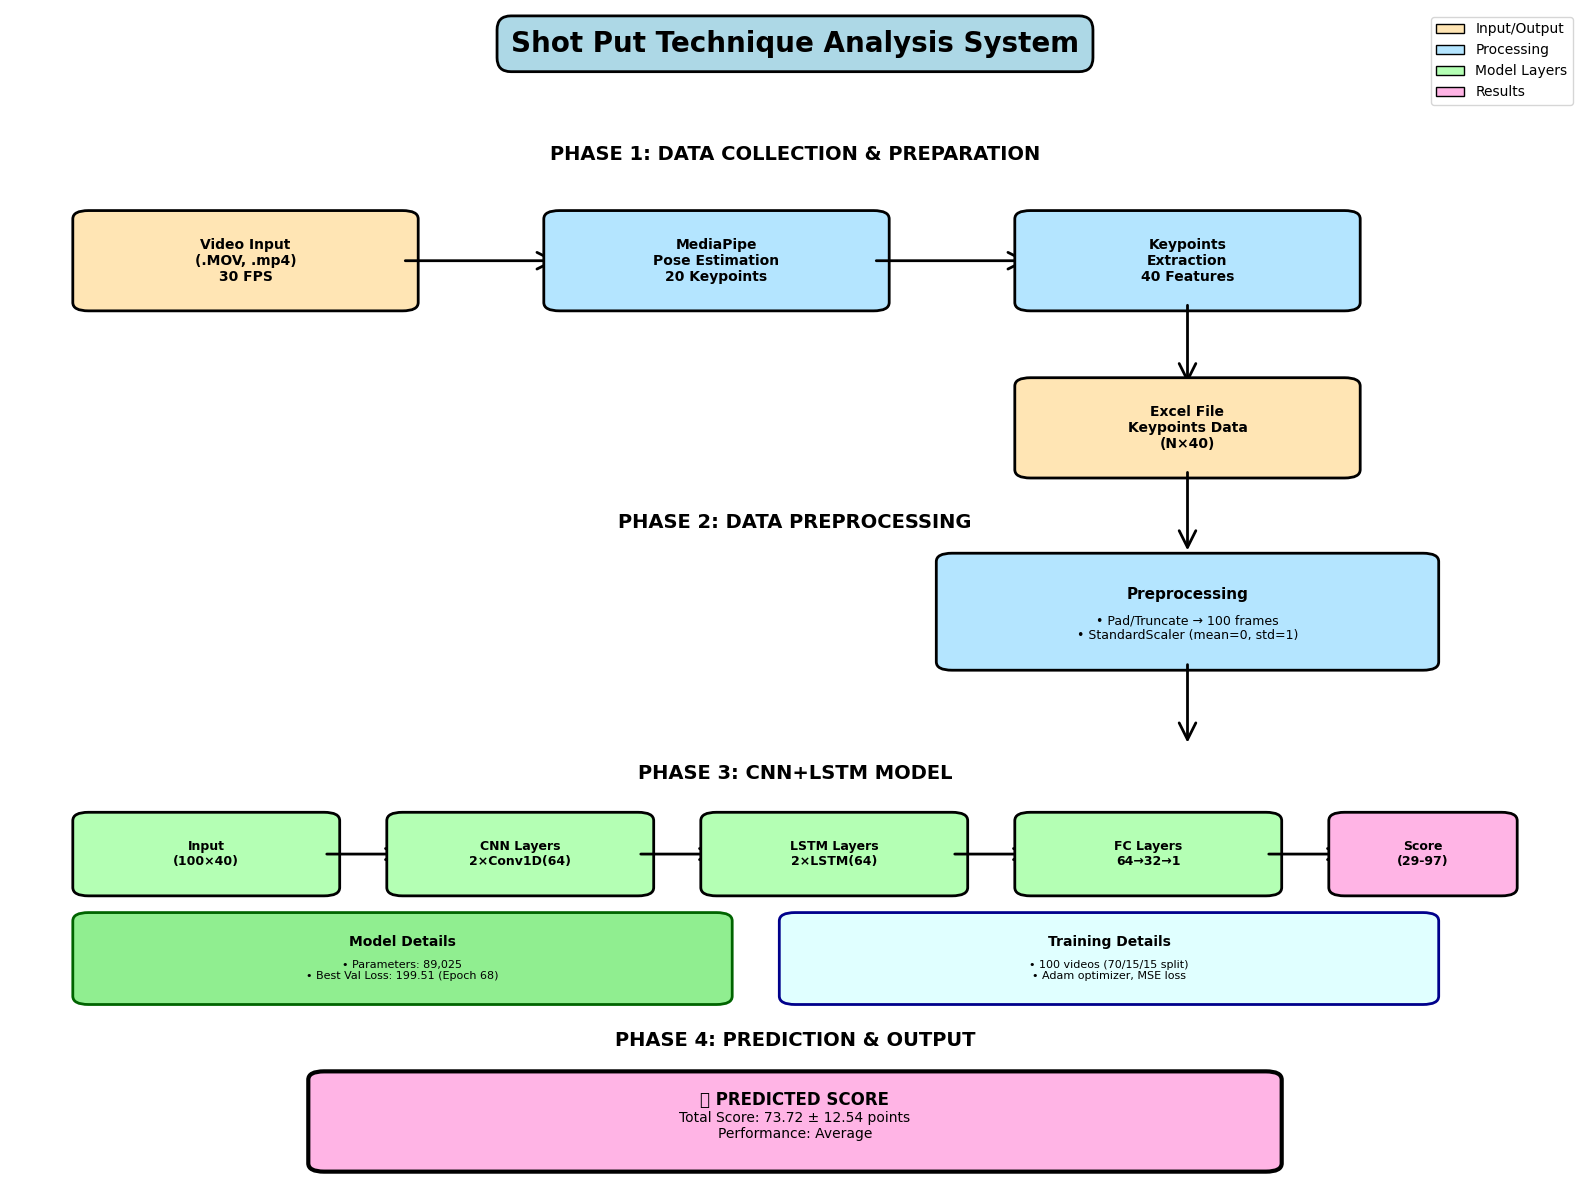


✅ Architecture diagram generated!
✅ Saved as: project_architecture_diagram.png


In [21]:
# Cell 7: Create Project Architecture Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

print("="*70)
print("📐 GENERATING PROJECT ARCHITECTURE DIAGRAM")
print("="*70)

fig, ax = plt.subplots(1, 1, figsize=(16, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

# Title
ax.text(5, 13.5, 'Shot Put Technique Analysis System', 
        fontsize=20, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='black', linewidth=2))

# Define colors
color_input = '#FFE5B4'
color_process = '#B4E5FF'
color_model = '#B4FFB4'
color_output = '#FFB4E5'

# PHASE 1: DATA COLLECTION
ax.text(5, 12.2, 'PHASE 1: DATA COLLECTION & PREPARATION', 
        fontsize=14, fontweight='bold', ha='center')

# Video Input
box1 = FancyBboxPatch((0.5, 10.5), 2, 1, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_input, linewidth=2)
ax.add_patch(box1)
ax.text(1.5, 11, 'Video Input\n(.MOV, .mp4)\n30 FPS', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Arrow
arrow1 = FancyArrowPatch((2.5, 11), (3.5, 11), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow1)

# MediaPipe Processing
box2 = FancyBboxPatch((3.5, 10.5), 2, 1, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_process, linewidth=2)
ax.add_patch(box2)
ax.text(4.5, 11, 'MediaPipe\nPose Estimation\n20 Keypoints', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Arrow
arrow2 = FancyArrowPatch((5.5, 11), (6.5, 11), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow2)

# Keypoints Extraction
box3 = FancyBboxPatch((6.5, 10.5), 2, 1, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_process, linewidth=2)
ax.add_patch(box3)
ax.text(7.5, 11, 'Keypoints\nExtraction\n40 Features', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Arrow down
arrow3 = FancyArrowPatch((7.5, 10.5), (7.5, 9.5), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow3)

# Excel Output
box4 = FancyBboxPatch((6.5, 8.5), 2, 1, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_input, linewidth=2)
ax.add_patch(box4)
ax.text(7.5, 9, 'Excel File\nKeypoints Data\n(N×40)', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# PHASE 2: PREPROCESSING
ax.text(5, 7.8, 'PHASE 2: DATA PREPROCESSING', 
        fontsize=14, fontweight='bold', ha='center')

# Arrow down
arrow4 = FancyArrowPatch((7.5, 8.5), (7.5, 7.5), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow4)

# Preprocessing steps
box5 = FancyBboxPatch((6, 6.2), 3, 1.2, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_process, linewidth=2)
ax.add_patch(box5)
ax.text(7.5, 7, 'Preprocessing', fontsize=11, ha='center', va='center', fontweight='bold')
ax.text(7.5, 6.6, '• Pad/Truncate → 100 frames\n• StandardScaler (mean=0, std=1)', 
        fontsize=9, ha='center', va='center')

# Arrow down
arrow5 = FancyArrowPatch((7.5, 6.2), (7.5, 5.2), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow5)

# PHASE 3: MODEL ARCHITECTURE
ax.text(5, 4.8, 'PHASE 3: CNN+LSTM MODEL', 
        fontsize=14, fontweight='bold', ha='center')

# Input Layer
box6 = FancyBboxPatch((0.5, 3.5), 1.5, 0.8, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_model, linewidth=2)
ax.add_patch(box6)
ax.text(1.25, 3.9, 'Input\n(100×40)', fontsize=9, ha='center', va='center', fontweight='bold')

# Arrow
arrow6 = FancyArrowPatch((2, 3.9), (2.5, 3.9), 
                        arrowstyle='->', mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow6)

# CNN Layers
box7 = FancyBboxPatch((2.5, 3.5), 1.5, 0.8, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_model, linewidth=2)
ax.add_patch(box7)
ax.text(3.25, 3.9, 'CNN Layers\n2×Conv1D(64)', fontsize=9, ha='center', va='center', fontweight='bold')

# Arrow
arrow7 = FancyArrowPatch((4, 3.9), (4.5, 3.9), 
                        arrowstyle='->', mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow7)

# LSTM Layers
box8 = FancyBboxPatch((4.5, 3.5), 1.5, 0.8, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_model, linewidth=2)
ax.add_patch(box8)
ax.text(5.25, 3.9, 'LSTM Layers\n2×LSTM(64)', fontsize=9, ha='center', va='center', fontweight='bold')

# Arrow
arrow8 = FancyArrowPatch((6, 3.9), (6.5, 3.9), 
                        arrowstyle='->', mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow8)

# FC Layers
box9 = FancyBboxPatch((6.5, 3.5), 1.5, 0.8, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_model, linewidth=2)
ax.add_patch(box9)
ax.text(7.25, 3.9, 'FC Layers\n64→32→1', fontsize=9, ha='center', va='center', fontweight='bold')

# Arrow
arrow9 = FancyArrowPatch((8, 3.9), (8.5, 3.9), 
                        arrowstyle='->', mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow9)

# Output
box10 = FancyBboxPatch((8.5, 3.5), 1, 0.8, boxstyle="round,pad=0.1", 
                       edgecolor='black', facecolor=color_output, linewidth=2)
ax.add_patch(box10)
ax.text(9, 3.9, 'Score\n(29-97)', fontsize=9, ha='center', va='center', fontweight='bold')

# Model Info Box
model_info = FancyBboxPatch((0.5, 2.2), 4, 0.9, boxstyle="round,pad=0.1", 
                            edgecolor='darkgreen', facecolor='lightgreen', linewidth=2)
ax.add_patch(model_info)
ax.text(2.5, 2.8, 'Model Details', fontsize=10, ha='center', fontweight='bold')
ax.text(2.5, 2.4, '• Parameters: 89,025\n• Best Val Loss: 199.51 (Epoch 68)', 
        fontsize=8, ha='center')

# Training Info Box
train_info = FancyBboxPatch((5, 2.2), 4, 0.9, boxstyle="round,pad=0.1", 
                            edgecolor='darkblue', facecolor='lightcyan', linewidth=2)
ax.add_patch(train_info)
ax.text(7, 2.8, 'Training Details', fontsize=10, ha='center', fontweight='bold')
ax.text(7, 2.4, '• 100 videos (70/15/15 split)\n• Adam optimizer, MSE loss', 
        fontsize=8, ha='center')

# PHASE 4: PREDICTION & OUTPUT
ax.text(5, 1.6, 'PHASE 4: PREDICTION & OUTPUT', 
        fontsize=14, fontweight='bold', ha='center')

# Prediction Result
result_box = FancyBboxPatch((2, 0.2), 6, 1, boxstyle="round,pad=0.1", 
                            edgecolor='black', facecolor=color_output, linewidth=3)
ax.add_patch(result_box)
ax.text(5, 0.9, '🎯 PREDICTED SCORE', fontsize=12, ha='center', fontweight='bold')
ax.text(5, 0.5, 'Total Score: 73.72 ± 12.54 points\nPerformance: Average', 
        fontsize=10, ha='center')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
    mpatches.Patch(facecolor=color_process, edgecolor='black', label='Processing'),
    mpatches.Patch(facecolor=color_model, edgecolor='black', label='Model Layers'),
    mpatches.Patch(facecolor=color_output, edgecolor='black', label='Results')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('project_architecture_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Architecture diagram generated!")
print("✅ Saved as: project_architecture_diagram.png")
print("="*70)